# Class Distribution

In [26]:
from datasets import load_dataset, concatenate_datasets
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

HF_REPO = "hamzamooraj99/AgriPath-LF16-30k"
NUM_CLASSES = 65

In [27]:
dataset = load_dataset(HF_REPO)
dataset = concatenate_datasets([
    dataset["train"],
    dataset["validation"],
    dataset["test"]
])

print(f"Columns: {dataset.column_names}")
# print(f"Columns: {large_dataset.column_names}")

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Columns: ['image', 'crop', 'disease', 'source', 'split', 'crop_disease_label', 'numeric_label']


In [28]:
keep_cols = ["numeric_label", "source"]
drop_cols = [c for c in dataset.column_names if c not in keep_cols]
dataset_small = dataset.remove_columns(drop_cols)

In [31]:
df = dataset_small.to_pandas()
df["numeric_label"] = df["numeric_label"].astype(int)

In [32]:
counts = (
    df.groupby(["numeric_label", "source"])
      .size()
      .unstack(fill_value=0)
      .reindex(range(NUM_CLASSES), fill_value=0)
)

## Combined

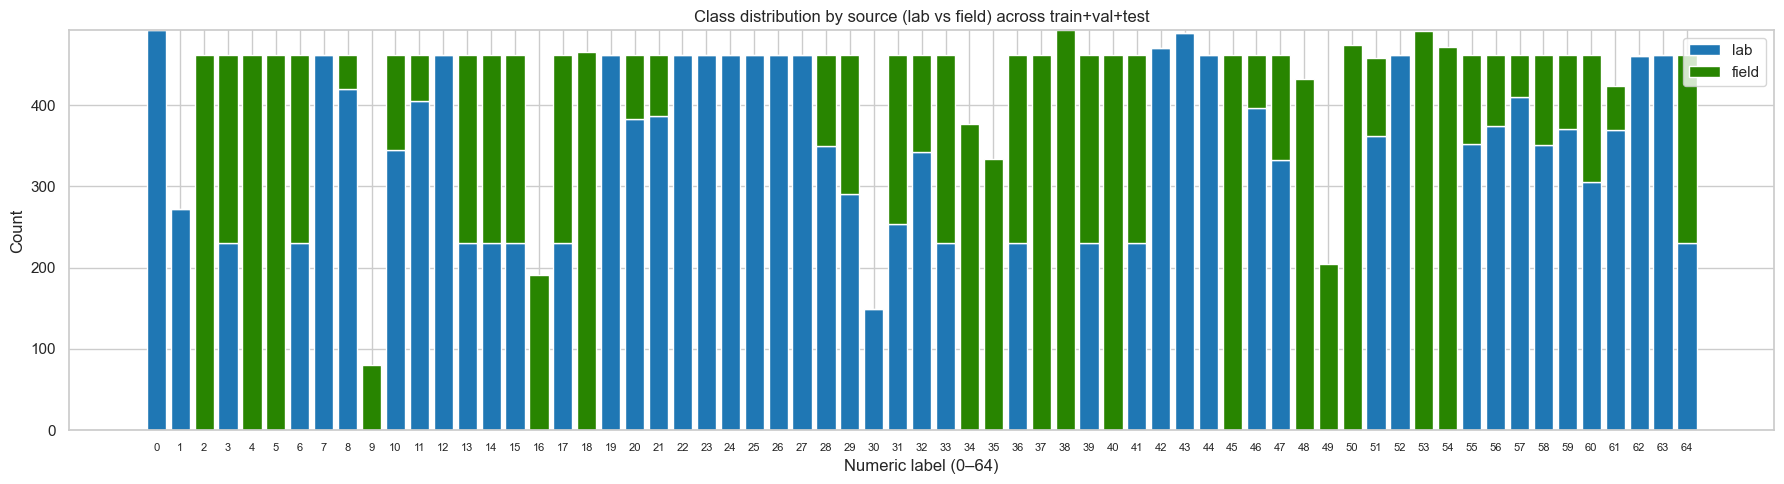

In [ ]:
lab_counts   = counts.get("lab", pd.Series([0]*NUM_CLASSES, index=range(NUM_CLASSES))).to_numpy()
field_counts = counts.get("field", pd.Series([0]*NUM_CLASSES, index=range(NUM_CLASSES))).to_numpy()


COLOR_LAB = "#1f77b4"    # blue
COLOR_FIELD = "#288500"  # orange

plt.figure(figsize=(18, 5))
plt.bar(x, lab_counts, label="lab", color=COLOR_LAB)
plt.bar(x, field_counts, bottom=lab_counts, label="field", color=COLOR_FIELD)

plt.xticks(x, [str(i) for i in x], rotation=0, fontsize=8)  # show 0–64 explicitly
plt.xlabel("Numeric label (0–64)")
plt.ylabel("Count")
plt.title("Class distribution (lab vs field)")
plt.legend()
plt.tight_layout()
plt.show()

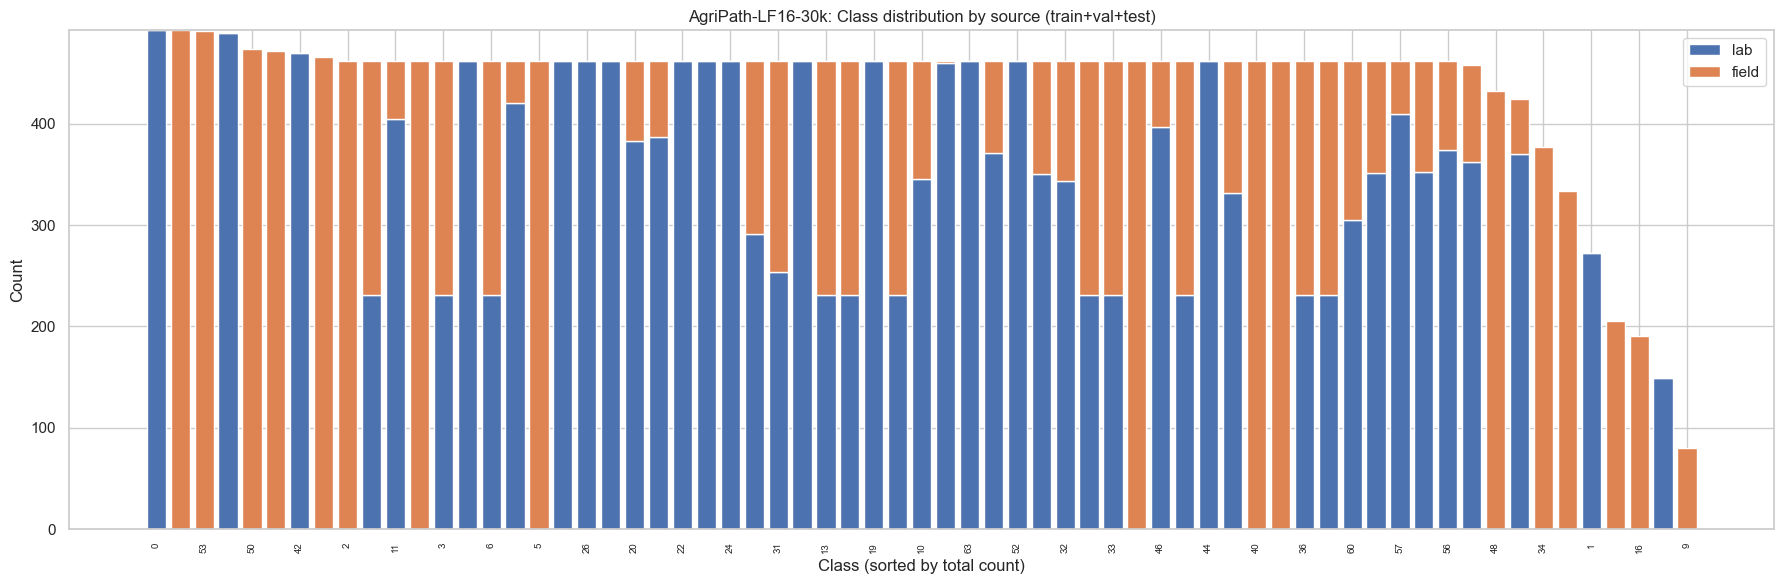

In [ ]:
plt.figure(figsize=(18,6))

sns.barplot(
    x=class_counts.index,
    y=class_counts.values,
    color="steelblue"
)

plt.xticks(rotation=0, fontsize=9)
plt.ylabel("Number of Samples")
plt.xlabel("Numeric Label")
plt.title("Class Distribution of AgriPath-LF16-30k")

plt.tight_layout()
plt.show()